In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import datasets, layers, models

In [2]:
(X_train,y_train),(X_test, y_test)= datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 37s 0us/step


In [3]:
X_train.shape

(50000, 32, 32, 3)

In [4]:
X_test.shape

(10000, 32, 32, 3)

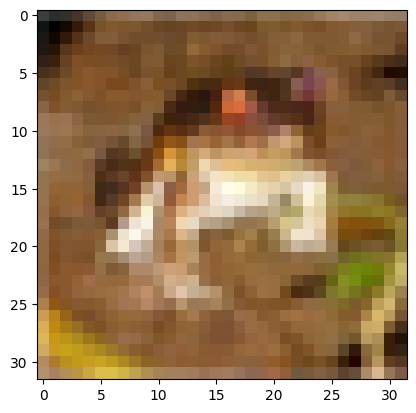

In [5]:
plt.imshow(X_train[0])

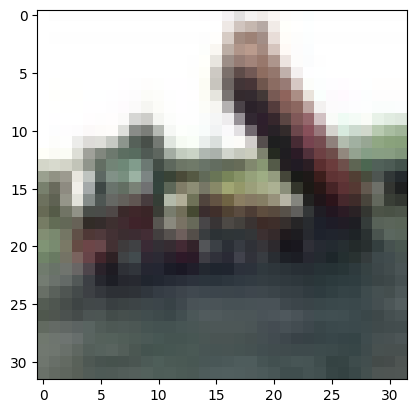

In [6]:
plt.imshow(X_train[2])

In [12]:
y_train.shape

(50000, 1)

In [13]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [14]:
#it is a two dimentional array and we dont need it.
y_train= y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [15]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [16]:
classes[6]

'frog'

In [17]:
def plot_sample(X,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

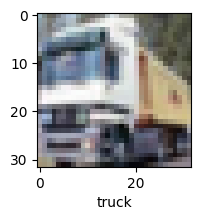

In [19]:
plot_sample(X_train, y_train, 1)

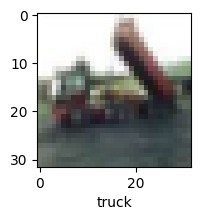

In [20]:
plot_sample(X_train, y_train, 2)

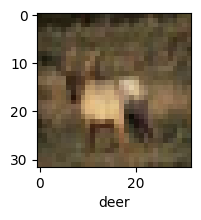

In [21]:
plot_sample(X_train, y_train, 3)

### Flattening the Data

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
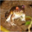

In [22]:
X_train[0]

In [24]:
# divide by 255 becuase they use rgb 255 values

X_train_scaled= X_train/255
X_test_scaled= X_test/255

## Model BUilding And Training

In [27]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='sigmoid') #10 neurons becuase have 10 category
])

ann.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann.fit(X_train,y_train, epochs=5)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3543 - loss: 1.8145
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4258 - loss: 1.6240
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4544 - loss: 1.5432
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4783 - loss: 1.4828
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4946 - loss: 1.4339


In [ ]:
#### we can categorical_crossentropy if the data is one hot encoded (zero and ones)
#### and if not one hot encoded the we will use sparse_ccategorical_crossentropy

## Evaluation

In [28]:
ann.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4781 - loss: 1.4672


[1.4671714305877686, 0.4781000018119812]

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.66      0.45      0.53      1000
           1       0.62      0.61      0.61      1000
           2       0.36      0.35      0.35      1000
           3       0.37      0.28      0.32      1000
           4       0.60      0.17      0.27      1000
           5       0.47      0.30      0.37      1000
           6       0.33      0.84      0.48      1000
           7       0.64      0.48      0.55      1000
           8       0.58      0.67      0.62      1000
           9       0.51      0.63      0.57      1000

    accuracy                           0.48     10000
   macro avg       0.51      0.48      0.47     10000
weighted avg       0.51      0.48      0.47     10000



### Using CNN to improve the accuracy

##### CNN has multiple layers:
  1. convolution+Relu
  2. Pooling.
  3. Covolution + RELU.
  4. Pooling
  5. Falttern
  
Convolution is detection features of the image

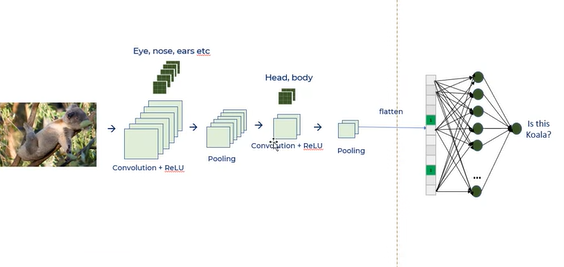

In [33]:
cnn = models.Sequential([
    # cnn
    layers.Conv2D(filters=32, kernel_size=(3,3), activation = 'relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(filters=32, kernel_size=(3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    #Dense
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') #softmax will normalize out values(zero to 1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
cnn.fit(X_test, y_test, epochs=10)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3246 - loss: 1.8551
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4618 - loss: 1.4927
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5190 - loss: 1.3431
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5508 - loss: 1.2433
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5935 - loss: 1.1589
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6209 - loss: 1.0806
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6380 - loss: 1.0103
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6617 - loss: 0.9568
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6832 - loss: 0.8997
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7073 - loss: 0.8493


In [37]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7519 - loss: 0.7436


[0.7435689568519592, 0.7519000172615051]

### we got 75 accuracy

In [40]:
y_test=y_test.reshape(-1,)

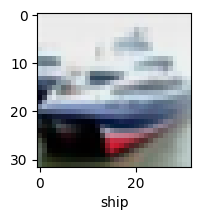

In [41]:
plot_sample(X_test, y_test, 1)

In [42]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[7.39974342e-03, 4.50963061e-03, 6.09362721e-02, 7.61727035e-01,
        3.07408031e-02, 7.59323388e-02, 2.27087624e-02, 1.16970018e-02,
        2.21082903e-02, 2.24007340e-03],
       [1.02924705e-01, 3.02600950e-01, 2.74950755e-04, 5.70171551e-06,
        1.01360594e-04, 8.81815140e-07, 2.30326307e-07, 1.83095221e-06,
        5.77475309e-01, 1.66140050e-02],
       [2.13684887e-02, 2.37346709e-01, 2.15656729e-03, 1.06012158e-03,
        2.65911082e-03, 2.89604650e-04, 1.56238777e-04, 3.40148603e-04,
        6.73603177e-01, 6.10199049e-02],
       [6.24863982e-01, 1.97753310e-02, 2.12549185e-03, 2.58451619e-04,
        3.51359625e-03, 1.20724135e-05, 7.64125070e-05, 6.87605689e-06,
        3.48430246e-01, 9.37506440e-04],
       [3.75483738e-04, 3.24262219e-04, 8.73495564e-02, 6.22475706e-02,
        1.53516680e-01, 4.67953086e-02, 6.48647547e-01, 3.83867533e-04,
        2.52402999e-04, 1.07292850e-04]], dtype=float32)

In [43]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6)]

In [44]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

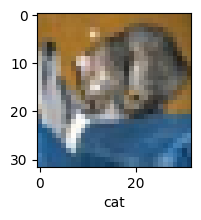

In [48]:
plot_sample(X_test, y_test, 0)

In [49]:
classes[y_classes[0]]

'cat'

In [51]:
print("classification Report", classification_report(y_test, y_classes))

classification Report               precision    recall  f1-score   support

           0       0.67      0.88      0.76      1000
           1       0.84      0.89      0.86      1000
           2       0.70      0.58      0.64      1000
           3       0.73      0.50      0.59      1000
           4       0.67      0.67      0.67      1000
           5       0.73      0.66      0.69      1000
           6       0.79      0.81      0.80      1000
           7       0.73      0.86      0.79      1000
           8       0.87      0.81      0.84      1000
           9       0.79      0.85      0.82      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000

